# L14b: Observer SSM, reading individual-stock returns off the market factor
In this lab we use the HiPPO-LegS structured state space model from the L14a lecture as a _market observer_. We build a single LegS filter on the daily log-growth rate of the S&P 500 ETF (ticker SPY), and for each ticker in `TICKER_ZOO` we fit a ticker-specific readout $\bar{\mathbf{C}}_\text{ticker}$ by closed-form ridge regression. The observer reads the market state at time $t$ (the LegS polynomial summary of SPY's trajectory up to $t$) and projects that state onto the individual ticker's return at the _same time_, extending CAPM's static $\beta$ to a dynamic, memory-aware linear factor model.

__Problem statement.__ We have daily OHLC bars for SPY plus the S&P 500 stocks in `TICKER_ZOO` covering 2014-01-03 through 2024-12-31 (training) and 2025 year-to-date (held out). We convert each close-price series into an annualized log-growth-rate sequence and, with SPY as the input, fit a zoo of ticker-specific HiPPO-LegS observers (one per entry of `TICKER_ZOO`) by closed-form ridge regression. We then pick one ticker, compare the observer's reconstruction to the true series in-sample and out-of-sample, and benchmark against a rolling-window ordinary-least-squares $\beta$ baseline.

Three points frame what to expect:

* __What the observer cannot learn:__ The model has no information beyond SPY. If a ticker's return is driven by an idiosyncratic news event that day, no amount of SPY history will explain it; the observer can only capture the part of the ticker that co-moves with the market factor.
* __What the observer does learn:__ A dynamic linear projection from the LegS polynomial summary of SPY's recent trajectory onto each ticker's current return. For tickers that are strongly SPY-coupled (large-caps like AAPL, MSFT), this should explain most of the daily return; for more idiosyncratic names, less.
* __Why that is the signal we want:__ A clean cross-asset correlation, with the trained $\bar{\mathbf{C}}_\text{ticker}$ generalizing from 2014-2024 to 2025 and beating a naive static-$\beta$ baseline, is the direct evidence that the LegS basis carries genuinely useful information about SPY's recent trajectory, not just its current value.

The rest of the notebook works toward this goal in three tasks: preparing the market and ticker data, training the observer zoo, and evaluating one observer against a rolling-$\beta$ baseline.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Frame cross-asset return projection as a HiPPO-LegS regression:__ Explain why choosing SPY as the input signal, keeping the LegS state and input matrices frozen, and fitting only the readout row vector extends static CAPM beta into a memory-aware linear factor model.
> * __Train and persist a zoo of readouts:__ Fit one ridge-regression readout per ticker against the shared SPY hidden state, save the full zoo to disk with its hidden dimension and time step, and load it back later without recomputing.
> * __Compare the observer to a rolling-beta baseline:__ Apply the trained observer and a rolling-window OLS beta to the same ticker in-sample and out-of-sample, and explain which of the two better captures the ticker's co-movement with SPY using correlation and mean-squared error.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

* [`src/Types.jl`](src/Types.jl) defines the `MySisoLegSHippoModel` struct.
* [`src/Compute.jl`](src/Compute.jl) defines `build_legS_matrices`, `discretize`, `build`, `rollout`, `solve`, `fit_C!`, `predict`, `log_growth_rate`, and the new `rolling_beta` helper used for the baseline.
* [`src/Files.jl`](src/Files.jl) defines `load_ohlc_dataset`, `save_observer_zoo`, and `load_observer_zoo`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating 

project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b`


### Constants
We'll use several constants throughout this lab. We define them here for easy reference and modification. See the comment next to each constant for an explanation of its purpose and units.

In [2]:
# --- market / signal constants ---------------------------------------------
MARKET_TICKER   = "SPY"              # ticker used as the input signal to the LegS filter
Δt              = 1.0 / 252.0        # trading-day sampling step in years (~252 trading days per year)

# --- ticker-zoo constants ----------------------------------------------------
TICKER_ZOO      = ["AAPL", "MSFT", "GOOG", "AMZN", "NFLX", "NVDA", "TSLA",
                   "JPM", "V", "JNJ", "WMT", "XOM", "UNH", "HD", "MA", "PG",
                   "BAC", "KO", "PEP", "CVX"]   # targets we train observers for

# --- observer / model constants ---------------------------------------------
H_OBSERVER      = 64                 # hidden dimension of the shared LegS filter on SPY
RIDGE_λ         = 1.0e-4             # ridge regularization for the closed-form readout fit
WARMUP_STEPS    = 25                 # out-of-sample rollout samples dropped so x_0 is forgotten
ZOO_PATH        = joinpath(_PATH_TO_DATA, "observer-zoo-N$(H_OBSERVER).jld2")  # pre-trained zoo file

# --- student-selectable ticker ----------------------------------------------
STUDENT_TICKER  = "AAPL"             # pick any ticker from TICKER_ZOO; everything below reads this

# --- rolling-beta baseline --------------------------------------------------
BETA_WINDOW     = 63                 # rolling OLS lookback in trading days (~3 months)

63

___

## Task 1: Prepare the market and ticker data
The first task is to turn the raw OHLC bars into the log-growth-rate sequences our observer and baseline will consume.

> __Data.__ Both files in [`data/`](data) are Polygon.io-sourced daily OHLC bars for twenty-one S&P 500 tickers (SPY plus the twenty in `TICKER_ZOO`). `SP500-Observer-Train-2014-2024.jld2` covers 2014-01-03 through 2024-12-31 ($T \approx 2767$ bars); `SP500-Observer-Test-2025.jld2` covers 2025 year-to-date ($T \approx 250$ bars). For every ticker we compute $g_{t} = (1/\Delta t)\log(P_{t}/P_{t-1})$ from the daily closes and collect the results in a `Dict{String, Vector{Float64}}`.

The code block below returns the market input sequence as `u_train::Vector{Float64}` and `u_test::Vector{Float64}`, and the per-ticker target dictionaries as `Y_train::Dict{String, Vector{Float64}}` and `Y_test::Dict{String, Vector{Float64}}`.

In [3]:
u_train, u_test, Y_train, Y_test = let

    # load the two (subsetted) OHLC dictionaries from disk
    train_ds = load_ohlc_dataset(joinpath(_PATH_TO_DATA, "SP500-Observer-Train-2014-2024.jld2"))
    test_ds  = load_ohlc_dataset(joinpath(_PATH_TO_DATA, "SP500-Observer-Test-2025.jld2"))
    @info "datasets loaded" n_train_tickers=length(train_ds) n_test_tickers=length(test_ds)

    # market input signal: SPY daily log-growth rate in both windows
    u_tr = log_growth_rate(train_ds[MARKET_TICKER].close; Δt = Δt)
    u_te = log_growth_rate(test_ds[MARKET_TICKER].close;  Δt = Δt)

    # per-ticker target sequences in both windows; assert length-match with the market signal
    # so that later fit_C!(model, u, y) calls never silently drop data or error mid-loop
    Y_tr = Dict{String, Vector{Float64}}()
    Y_te = Dict{String, Vector{Float64}}()
    for t in TICKER_ZOO
        y_tr = log_growth_rate(train_ds[t].close; Δt = Δt)
        y_te = log_growth_rate(test_ds[t].close;  Δt = Δt)
        length(y_tr) == length(u_tr) || error("ticker $(t) has $(length(y_tr)) train rows, expected $(length(u_tr)) to match SPY")
        length(y_te) == length(u_te) || error("ticker $(t) has $(length(y_te)) test rows, expected $(length(u_te)) to match SPY")
        Y_tr[t] = y_tr
        Y_te[t] = y_te
    end
    @info "growth rates computed" T_train=length(u_tr) T_test=length(u_te) n_targets=length(Y_tr)

    (u_tr, u_te, Y_tr, Y_te)
end;

┌ Info: datasets loaded
│   n_train_tickers = 21
└   n_test_tickers = 21
┌ Info: growth rates computed
│   T_train = 2766
│   T_test = 249
└   n_targets = 20


### Visualize the market input and the student-selected target
We plot SPY (the input signal) on top and the student's target ticker underneath so you can eyeball how strongly the two move together. For daily returns the overlap is usually dramatic for large-cap names, which is what lets the observer work at all.

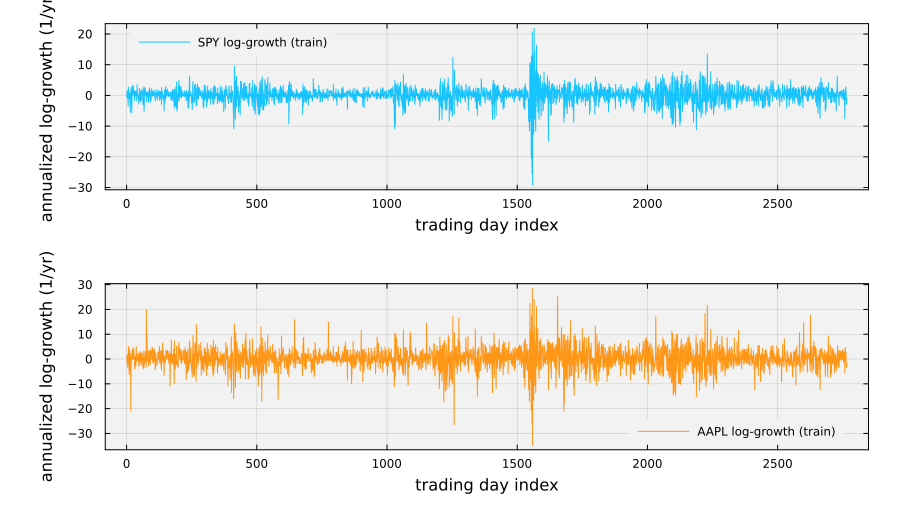

In [4]:
let
    l = @layout [a; b]
    p1 = plot(u_train;
        label = "$(MARKET_TICKER) log-growth (train)",
        xlabel = "trading day index", ylabel = "annualized log-growth (1/yr)",
        lw = 1.0, c = :deepskyblue, alpha = 0.9,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    p2 = plot(Y_train[STUDENT_TICKER];
        label = "$(STUDENT_TICKER) log-growth (train)",
        xlabel = "trading day index", ylabel = "annualized log-growth (1/yr)",
        lw = 1.0, c = :darkorange, alpha = 0.9,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __How co-moving are SPY and `STUDENT_TICKER` in the training window?__ Using only the two time-series above and the simple statistic $\rho(u_\text{train}, Y_\text{train}[\text{STUDENT\_TICKER}])$ (no new code required below; you can compute it inline if you want): (a) does the bulk of the ticker's day-to-day variation line up with SPY's, or are there many large swings in the ticker that SPY does not share? (b) What does that visual co-movement imply about the maximum $\rho$ any observer or baseline can hope to achieve on this ticker using SPY alone as an input?

___

## Task 2: Train the observer zoo
The second task is to build a single HiPPO-LegS filter on SPY (shared across all tickers) and fit one readout row vector per ticker by closed-form ridge regression.

> __Observer zoo.__ We construct one `MySisoLegSHippoModel` at hidden dimension $h$ (set by `H_OBSERVER`) with SPY as the input, so the discretized $(\bar{\mathbf{A}}, \bar{\mathbf{B}})$ are fixed by the LegS theory and do not depend on the target. For every ticker in `TICKER_ZOO` we roll the same hidden-state matrix $\mathbf{X}\in\mathbb{R}^{T\times h}$ forward on SPY and then fit $\bar{\mathbf{C}}_\text{ticker}$ by ridge regression against the ticker's log-growth rate via [`fit_C!`](src/Compute.jl). The full zoo is a `Dict{String, Matrix{Float64}}` keyed by ticker whose values are the $1\times h$ readout rows; it is saved to [`ZOO_PATH`](data) so downstream cells can reload it without retraining. If a cached zoo exists we skip the fit entirely.

The code block below returns the full zoo as `zoo::Dict{String, Matrix{Float64}}` and the shared LegS filter as `market_model::MySisoLegSHippoModel` (with $\bar{\mathbf{C}} = \mathbf{0}$; each ticker's $\bar{\mathbf{C}}$ lives in the `zoo` dictionary).

In [5]:
zoo, market_model = let

    # build the shared LegS filter on SPY (A, B, Ā, B̄ are fixed by construction)
    Random.seed!(42);
    mmodel = build(MySisoLegSHippoModel; h = H_OBSERVER, Δt = Δt)

    # if a cached zoo exists, load it and reuse the readouts; otherwise train fresh
    local z::Dict{String, Matrix{Float64}}
    if isfile(ZOO_PATH)
        (z, hfile, Δtfile) = load_observer_zoo(ZOO_PATH)
        @assert hfile == H_OBSERVER "cached zoo h=$(hfile) does not match H_OBSERVER=$(H_OBSERVER); delete $(ZOO_PATH) to retrain"
        @assert isapprox(Δtfile, Δt) "cached zoo Δt=$(Δtfile) does not match current Δt=$(Δt); delete $(ZOO_PATH) to retrain"
        @info "loaded cached zoo" path=ZOO_PATH n_tickers=length(z) h=hfile
    else
        z = Dict{String, Matrix{Float64}}()
        @info "no cached zoo found; training..." path=ZOO_PATH n_tickers=length(TICKER_ZOO) h=H_OBSERVER
        for t in TICKER_ZOO
            # fresh model per ticker so fit_C! writes into a clean C; only the C row is persisted
            m = build(MySisoLegSHippoModel; h = H_OBSERVER, Δt = Δt)
            fit_C!(m, u_train, Y_train[t]; λ = RIDGE_λ)
            z[t] = copy(m.C)
        end
        save_observer_zoo(ZOO_PATH, z; h = H_OBSERVER, Δt = Δt)
        @info "trained + cached zoo" path=ZOO_PATH n_tickers=length(z) bytes=filesize(ZOO_PATH)
    end

    (z, mmodel)
end;

┌ Info: loaded cached zoo
│   path = "/Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b/data/observer-zoo-N64.jld2"
│   n_tickers = 20
└   h = 64


### In-sample fit quality across the zoo
Before picking one ticker, let's tabulate the in-sample reconstruction correlation for every observer in the zoo. This gives us a first look at which tickers are well-explained by SPY's trajectory and which are not.

The code block below returns the in-sample metrics as `zoo_metrics::DataFrame` with one row per ticker.

In [ ]:
zoo_metrics = let
    # roll the shared hidden state once on SPY; C varies by ticker but X does not
    X_train, _ = solve(market_model, u_train)
    df = DataFrame(ticker = String[], ρ_in = Float64[], mse_in = Float64[])
    for t in TICKER_ZOO
        yhat = (X_train * zoo[t]')[:, 1]
        push!(df, (t, cor(Y_train[t], yhat), mean((Y_train[t] .- yhat).^2)))
    end
    sort!(df, :ρ_in; rev = true)
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

### Things to think about
* __Which tickers does SPY explain best, and does that ranking make sense?__ Using only the `zoo_metrics` table above (no new code): (a) which three tickers have the highest in-sample $\rho$, and do they share a common property (sector, market cap, index weight)? (b) Which three are hardest for SPY alone to explain, and what does that tell you about the limits of a single-market-factor observer? Put the two observations together: does the ranking line up with what you would predict from CAPM intuition (names with larger SPY-correlation should be better explained)?

___

## Task 3: Evaluate on the student-selected ticker and compare to a rolling-beta baseline
The third task applies the observer for `STUDENT_TICKER` to the 2025 holdout input and benchmarks it against a rolling-window OLS $\beta$ baseline fit on the same data.

> __Observer evaluation.__ We form the ticker's observer prediction in two windows. In-sample we apply $\bar{\mathbf{C}}_\text{STUDENT\_TICKER}$ to the hidden state rolled out on `u_train`. Out-of-sample we apply the same $\bar{\mathbf{C}}$ to the hidden state rolled out on `u_test`, dropping the first `WARMUP_STEPS` samples via [`predict`](src/Compute.jl) so that $\mathbf{x}_{0} = \mathbf{0}$ is forgotten before we compare. Crucially, $\bar{\mathbf{C}}$ is frozen at its Task 2 value; the observer never sees 2025 data during evaluation.

> __Rolling-beta baseline.__ At every day $t$ we fit the static CAPM regression
>
> $$y_\tau \;=\; \alpha \;+\; \beta\, u_\tau \;+\; \varepsilon_\tau, \qquad \tau \in \{t - W,\,\ldots,\,t - 1\},$$
>
> on the trailing $W$ = `BETA_WINDOW` days by ordinary least squares. The window slope and intercept are
>
> $$\hat{\beta}_t \;=\; \frac{\sum_{\tau = t - W}^{t - 1} (u_\tau - \bar{u}_t)(y_\tau - \bar{y}_t)}{\sum_{\tau = t - W}^{t - 1} (u_\tau - \bar{u}_t)^2}, \qquad \hat{\alpha}_t \;=\; \bar{y}_t - \hat{\beta}_t\,\bar{u}_t,$$
>
> where $\bar{u}_t, \bar{y}_t$ are the trailing-window means. The one-step prediction is $\hat{y}_t = \hat{\alpha}_t + \hat{\beta}_t\, u_t$. The implementation is in [`rolling_beta`](src/Compute.jl).

> __Apples-to-oranges caveat.__ The two models do not have symmetric access to the 2025 holdout. The observer's readout $\bar{\mathbf{C}}$ is trained once on 2014-2024 and then frozen, so every prediction it makes on 2025 is a true out-of-sample extrapolation. The rolling-beta baseline, by contrast, refits $(\hat{\alpha}_t, \hat{\beta}_t)$ every day on the trailing `BETA_WINDOW` days, so during 2025 it is continuously adapting to the new regime using the most recent observations of the ticker's return (information the observer never touches). The comparison is therefore biased in favor of the baseline: if the frozen observer still ties or beats rolling beta on 2025, the SSM basis is carrying genuine signal; if rolling beta wins, some of that lead is paid for by its ongoing parameter updates, not by a better inductive bias.

Both models still use the contemporaneous SPY value to predict the ticker's return, so they are directly comparable on correlation and MSE at each time $t$. The code block below stores the observer's in-sample output as `ŷ_in::Vector{Float64}`, the warmup-trimmed out-of-sample output as `ŷ_oos::Vector{Float64}`, and the rolling-beta baseline's in-sample and out-of-sample predictions as `β_in::Vector{Float64}` and `β_oos::Vector{Float64}`.

In [7]:
ŷ_in, ŷ_oos, β_in, β_oos = let
    @info "evaluating observer" ticker=STUDENT_TICKER h=H_OBSERVER

    # --- observer: install the student's trained C into the shared market_model
    m = deepcopy(market_model)
    m.C = copy(zoo[STUDENT_TICKER])

    # --- in-sample observer
    (_, yhat_in) = solve(m, u_train)

    # --- out-of-sample observer (drop first WARMUP_STEPS samples)
    (_, yhat_oos) = predict(m, u_test; warmup = WARMUP_STEPS)

    # --- rolling-beta baseline: fit on the preceding BETA_WINDOW days, predict current point
    (_, _, bhat_in)  = rolling_beta(u_train, Y_train[STUDENT_TICKER]; window = BETA_WINDOW)
    (_, _, bhat_oos) = rolling_beta(u_test,  Y_test[STUDENT_TICKER];  window = BETA_WINDOW)

    @info "observer vs rolling-beta (in-sample)" ρ_obs=round(cor(Y_train[STUDENT_TICKER], yhat_in), digits=4) ρ_β=round(cor(filter(!isnan, bhat_in), Y_train[STUDENT_TICKER][BETA_WINDOW+1:end]), digits=4)
    (yhat_in, yhat_oos, bhat_in, bhat_oos)
end;

┌ Info: evaluating observer
│   ticker = "AAPL"
└   h = 64
┌ Info: observer vs rolling-beta (in-sample)
│   ρ_obs = 0.742
└   ρ_β = 0.7346


### In-sample fit: observer versus rolling beta
Two panels: the full in-sample time series with all three curves overlaid, and a scatter of observer-vs-truth showing how tight the memorize-like fit is.

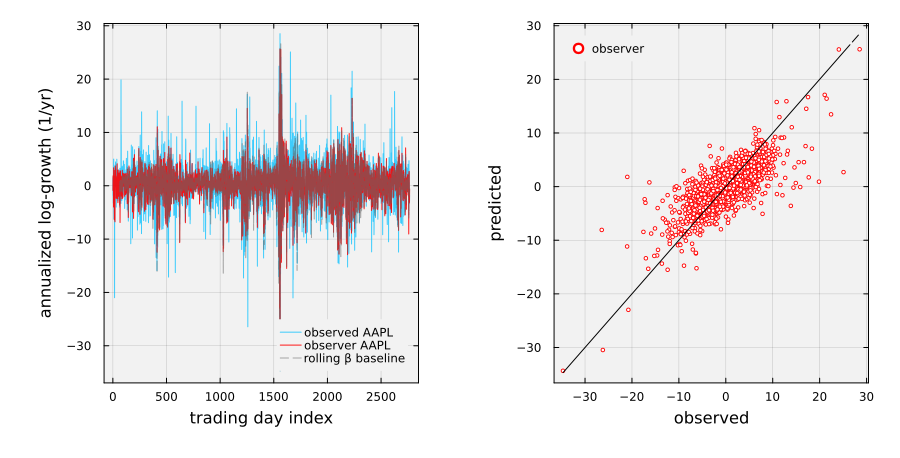

In [8]:
let
    l = @layout [a b]
    p1 = plot(Y_train[STUDENT_TICKER];
        label = "observed $(STUDENT_TICKER)",
        xlabel = "trading day index", ylabel = "annualized log-growth (1/yr)",
        lw = 1.0, c = :deepskyblue, alpha = 0.75,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, ŷ_in;                  label = "observer $(STUDENT_TICKER)", lw = 1.0, c = :red, alpha = 0.9)
    plot!(p1, β_in;                  label = "rolling β baseline",         lw = 1.0, c = :gray40, alpha = 0.6, ls = :dash)

    p2 = scatter(Y_train[STUDENT_TICKER], ŷ_in;
        label = "observer", xlabel = "observed", ylabel = "predicted",
        c = :white, msc = :red, markersize = 2,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p2, Y_train[STUDENT_TICKER], Y_train[STUDENT_TICKER];
        label = "", c = :black, lw = 1, ls = :dash)

    plot(p1, p2; layout = l, size = (900, 460),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Out-of-sample fit: observer versus rolling beta
Same overlay on the 2025 holdout. This is the honest test: neither model was fit on 2025 data, and we are asking whether the SPY-conditioned linear projection trained on 2014-2024 still explains the ticker in a new year.

In [ ]:
let
    l = @layout [a b]
    y_te    = Y_test[STUDENT_TICKER][(WARMUP_STEPS + 1):end]   # observer target, warmup-trimmed
    β_te    = β_oos[(WARMUP_STEPS + 1):end]                    # baseline prediction, aligned
    t_axis  = (WARMUP_STEPS + 1):length(Y_test[STUDENT_TICKER])

    p1 = plot(t_axis, y_te;
        label = "observed $(STUDENT_TICKER) (2025)",
        xlabel = "trading day index (2025, post-warmup)", ylabel = "annualized log-growth (1/yr)",
        lw = 1.2, c = :deepskyblue, alpha = 0.85,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, t_axis, ŷ_oos;  label = "observer",             lw = 1.2, c = :red, alpha = 0.9)
    plot!(p1, t_axis, β_te;   label = "rolling β baseline",    lw = 1.2, c = :gray40, alpha = 0.6, ls = :dash)

    # metrics table, ignoring any NaNs in the baseline from points that fall before one full window
    mask = .!isnan.(β_te)
    ρ_obs = cor(y_te, ŷ_oos)
    ρ_β   = cor(y_te[mask], β_te[mask])
    mse_obs = mean((y_te .- ŷ_oos).^2)
    mse_β   = mean((y_te[mask] .- β_te[mask]).^2)
    summary = DataFrame(
        model = ["observer (h = $(H_OBSERVER))", "rolling β (window = $(BETA_WINDOW))"],
        ρ_oos = [ρ_obs, ρ_β],
        mse_oos = [mse_obs, mse_β])
    pretty_table(summary; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])

    p2 = density(y_te; label = "observed $(STUDENT_TICKER) (2025)",
        lw = 2, c = :deepskyblue,
        xlabel = "annualized log-growth (1/yr)", ylabel = "density",
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    density!(p2, ŷ_oos; label = "observer", lw = 2, c = :red)
    density!(p2, β_te[mask]; label = "rolling β", lw = 2, c = :gray40, ls = :dash)

    plot(p1, p2; layout = l, size = (900, 460),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __Observer versus rolling $\beta$: what does the extra memory buy you?__ Using only the time-series overlays and the metrics table above (no retraining): (a) On 2025 holdout, which model has the higher correlation with the observed ticker, and by how much? (b) Does the observer's extra memory ($h$ polynomial coefficients of SPY's recent trajectory, set by `H_OBSERVER`) translate into a meaningfully different out-of-sample fit, or does a single contemporaneous $\beta$ already capture most of what SPY can tell you about this ticker? Put the two observations together: for the selected `STUDENT_TICKER`, does the SSM observer add a useful correction on top of rolling CAPM beta, or is it essentially equivalent?

___

## Summary
This notebook used a single HiPPO-LegS filter on SPY as a market observer and fit a zoo of ticker-specific readouts (one per entry of `TICKER_ZOO`) by closed-form ridge regression, extending the static CAPM beta into a memory-aware linear factor model. We saved the zoo to disk once, then picked one ticker and compared the observer's in-sample and out-of-sample projections to a rolling-window OLS beta baseline using the same SPY input.

> __Key Takeaways:__
>
> * **The observer zoo is cheap to persist and explore:** Because the LegS state and input matrices are shared across all tickers, only the per-ticker readout row vector needs to be stored, so the full zoo fits in well under a megabyte and a student can swap `STUDENT_TICKER` and rerun Task 3 without retraining anything.
> * **A single-factor observer explains big-cap S&P tickers well, but not all equally:** The in-sample reconstruction correlation is high for broad-market-correlated names and lower for idiosyncratic ones, which matches CAPM intuition about what a single market factor can and cannot capture.
> * **Memory helps, but only when SPY's trajectory carries signal beyond its current value:** For daily returns on names that are almost entirely explained by contemporaneous market moves, the observer ties the rolling-beta baseline; the observer's advantage grows on tickers whose co-movement with SPY has persistent lagged structure that a single-step beta cannot see.

___